In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('advertising.csv')
len(df)

200

In [3]:
#df.head()

# initial data inspection

In [4]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
#df.describe()

# Exploratory Data analysis(EDA)

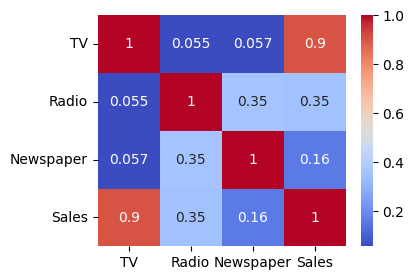

In [7]:
import seaborn as sns
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

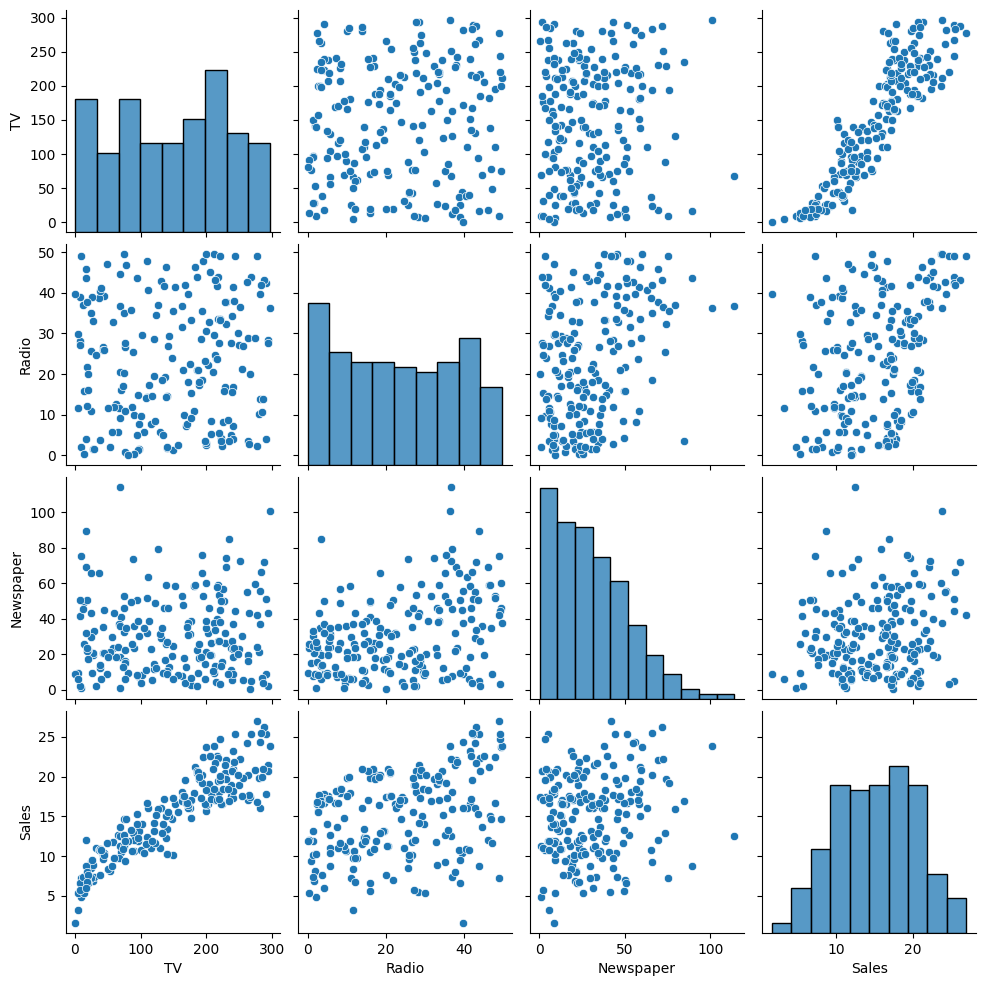

In [8]:
sns.pairplot(df)
plt.show()

# Statistical analysis & feature selection

In [9]:
import statsmodels.api as sm
cdf=df[['TV','Radio','Newspaper']]
y=df['Sales']
X = sm.add_constant(cdf)
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           8.13e-99
Time:                        19:50:12   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(cdf.shape[1]):
    vif.append(variance_inflation_factor(cdf.values,i))
print(vif)  

[np.float64(1.00461078493965), np.float64(1.1449519171055356), np.float64(1.1451873787239288)]


In [11]:
#msk=np.random.rand(len(df))<0.8 
#train=df[msk] 
#test=df[~msk] 
#x_train=np.asanyarray(train[['TV','Radio']])
#y_train=np.asanyarray(train[['Sales']])
#x_test=np.asanyarray(test[['TV','Radio']])
#y_test=np.asanyarray(test[['Sales']])
#len(df[msk])

## train test split

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
# Sample data
X=df[['TV','Radio']]
Y =df['Sales']
# Splitting data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("X_train:\n", x_train)
print("X_test:\n", x_test)
print("y_train:\n", y_train)
print("y_test:\n", y_test)

X_train:
         TV  Radio
79   116.0    7.7
197  177.0    9.3
38    43.1   26.7
24    62.3   12.6
122  224.0    2.4
..     ...    ...
106   25.0   11.0
14   204.1   32.9
92   217.7   33.5
179  165.6   10.0
102  280.2   10.1

[160 rows x 2 columns]
X_test:
         TV  Radio
95   163.3   31.6
15   195.4   47.7
30   292.9   28.3
158   11.7   36.9
128  220.3   49.0
115   75.1   35.0
69   216.8   43.9
170   50.0   11.6
174  222.4    3.4
45   175.1   22.5
66    31.5   24.6
182   56.2    5.7
165  234.5    3.4
78     5.4   29.9
186  139.5    2.1
177  170.2    7.8
56     7.3   28.1
152  197.6   23.3
82    75.3   20.3
68   237.4   27.5
124  229.5   32.3
16    67.8   36.6
148   38.0   40.3
93   250.9   36.5
65    69.0    9.3
60    53.5    2.0
84   213.5   43.0
67   139.3   14.5
125   87.2   11.8
132    8.4   27.2
9    199.8    2.6
18    69.2   20.5
55   198.9   49.4
75    16.9   43.7
150  280.7   13.9
104  238.2   34.3
135   48.3   47.0
137  273.7   28.9
164  117.2   14.7
76    27.5    1.6
y_t

In [13]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
print(regr.coef_)
print(regr.intercept_)

[0.05450736 0.10325764]
4.791381661776025


In [15]:
from sklearn.metrics import r2_score
y_train_pred=regr.predict(x_train)
r2_train=r2_score(y_train,y_train_pred)
adjusted_r2=1-(1-r2_train)*(len(y_train)-1)/(len(y_train)-2-1)
print("R2-scoretrain: %.3f" % r2_score(y_train , y_train_pred) )
print("adjusted r2train: %.3f" % adjusted_r2)

R2-scoretrain: 0.900
adjusted r2train: 0.899


#  model evaluation

In [16]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
y_pred = regr.predict(x_test)
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_pred-y_test)))
print("Mean squared error (MSE): %.2f" % np.mean((y_pred-y_test) ** 2))
print("R2-score: %.3f" % r2_score(y_test , y_pred) )
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("rmse: %.2f" %rmse)

Mean absolute error: 1.27
Residual sum of squares (MSE): 2.85
R2-score: 0.908
rmse: 1.69


# residual analysis

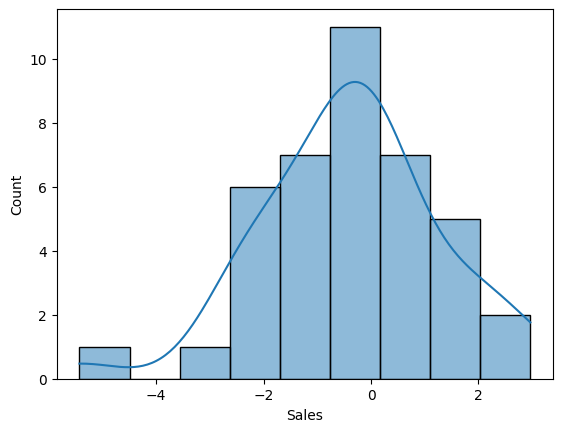

In [17]:
residuals = y_test - y_pred
sns.histplot(residuals,kde=True)
plt.show()

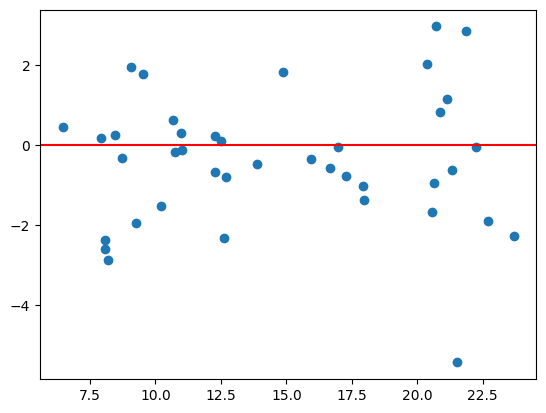

In [18]:
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red')
plt.show()

In [19]:
from scipy.stats import shapiro

shapiro(residuals)

ShapiroResult(statistic=np.float64(0.971346689495279), pvalue=np.float64(0.3966464156486731))

# Cross validation

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    regr,
    df[['TV','Radio']],
    df['Sales'],
    cv=5,
    scoring='r2'
)

print(scores.mean())

0.8958535029714983


C:\Users\LENOVO\newp\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


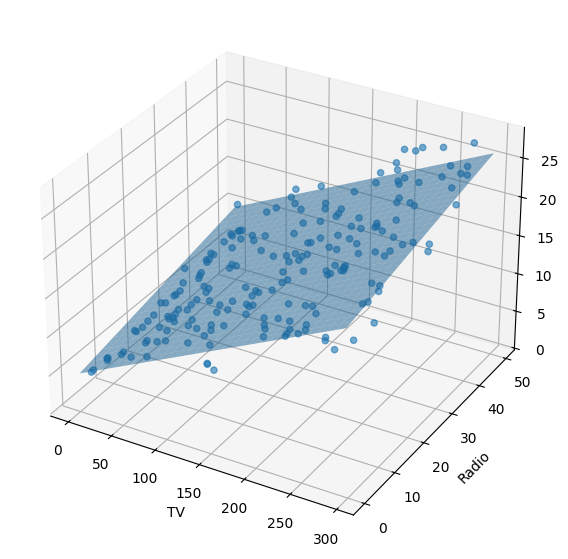

In [27]:
# ساختن محدوده‌ای از مقادیر TV و Radio
tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 30)
radio_range = np.linspace(df['Radio'].min(), df['Radio'].max(), 30)
# ساختن شبکه‌ای از تمام ترکیب‌های TV و Radio
X, Y = np.meshgrid(tv_range, radio_range)
# پیش‌بینی Sales برای تمام نقاط شبکه
Z = regr.predict(
    np.c_[X.ravel(), Y.ravel()]
).reshape(X.shape)
# رسم نمودار سه‌بعدی
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# داده‌های واقعی
ax.scatter(
    df['TV'],
    df['Radio'],
    df['Sales'],
    alpha=0.6
)
# صفحه‌ی رگرسیون
ax.plot_surface(
    X,
    Y,
    Z,
    alpha=0.5
)

ax.set_xlabel('TV')
ax.set_ylabel('Radio')
ax.set_zlabel('Sales')

plt.show()

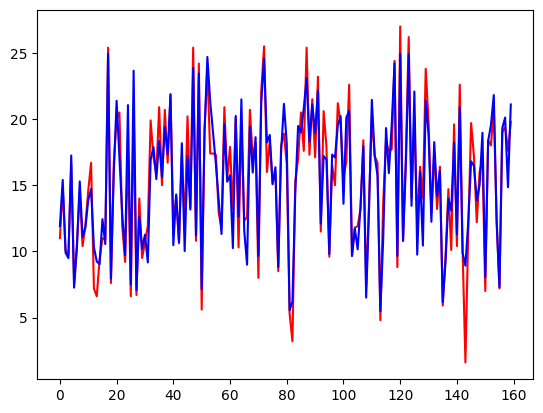

In [25]:
yytrain=y_train.tolist()
yytrainpred=y_train_pred.tolist()
plt.plot(yytrain,'r-',yytrainpred,'b-')

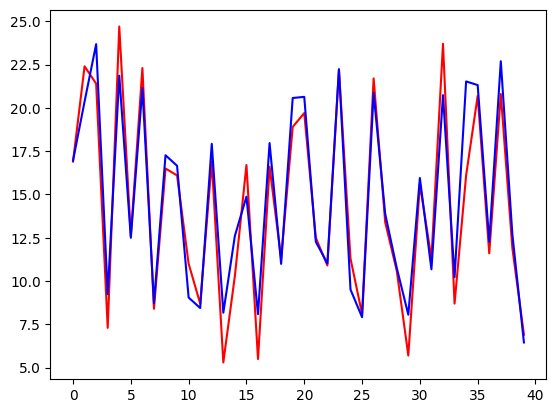

In [26]:
yytest=y_test.tolist()
yytestpred=y_pred.tolist()
plt.plot(yytest,'r-',yytestpred,'b-')